# Phase 5 — Models

Two feature sets, two algorithms, two splits. Eight rows, and three findings.

The baseline is `grid` and `lap`. It already controls for fuel burn and track evolution,
because within one race both are monotonic in lap number. It knows nothing about tires. The
enhanced set adds `tire_age`, `tire_age_sq` and `stint_number`.

That is what makes the comparison fair: any gain is attributable to tire information rather
than to a confound the baseline was missing.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

from cleaning import clean
from data_loader import load_pit_stops
from dataset import build_lap_table
from features import add_features
from models import (
    evaluate,
    extrapolation_check,
    improvement_table,
    tire_age_coefficient,
)

race, selected, laps = build_lap_table()
stops = load_pit_stops()
stops = stops[stops["raceId"] == race["raceId"]]
featured = add_features(clean(laps, stops)[0], stops)

results = evaluate(featured)
results.to_csv(ROOT / "results" / "model_comparison.csv", index=False)
results

,split,features,algorithm,rmse,mae,n_train,n_test
0,random,baseline,LinearRegression,0.915489,0.741566,328,82
1,random,baseline,RandomForest,0.636638,0.416773,328,82
2,random,enhanced,LinearRegression,0.707994,0.543236,328,82
3,random,enhanced,RandomForest,0.487979,0.379170,328,82
4,stint,baseline,LinearRegression,1.071363,0.866345,248,162
5,stint,baseline,RandomForest,1.579403,1.299540,248,162
6,stint,enhanced,LinearRegression,0.906846,0.703241,248,162
7,stint,enhanced,RandomForest,1.136972,0.938444,248,162


## Finding 1 — tire age helps, on every combination

The research question has a clear answer. Adding tire information improves RMSE in all four
pairings, by 15% to 28%.

In [2]:
gains = improvement_table(results)
gains.to_csv(ROOT / "results" / "improvement.csv", index=False)
gains

features,split,algorithm,baseline,enhanced,rmse_gain,rmse_gain_pct
0,random,LinearRegression,0.9155,0.7080,0.2075,22.6650
1,random,RandomForest,0.6366,0.4880,0.1487,23.3507
2,stint,LinearRegression,1.0714,0.9068,0.1645,15.3559
3,stint,RandomForest,1.5794,1.1370,0.4424,28.0126


**The honest headline.** On the stint split with linear regression, RMSE falls from 1.071s
to 0.907s, a 15.4% improvement. That is the number to quote, because it is the one measured
without leakage.

## Finding 2 — the leaked split does not just flatter, it reverses the verdict

This is the important result.

Compare the two algorithms on the enhanced feature set, once under each split:

| Split | LinearRegression | RandomForest | Which looks better? |
| :-- | --: | --: | :-- |
| Random (leaky) | 0.708 | **0.488** | RandomForest, by 31% |
| Stint (honest) | **0.907** | 1.137 | LinearRegression, by 20% |

A random split would not merely report an over-optimistic score. It would lead to picking the
**wrong model**. RandomForest looks like the clear winner under leakage and is in fact the
worse of the two once the leak is closed.

The reason is mechanical. A tree predicts by averaging the training points that land in the
same leaf. When 95.1% of test laps have an immediate neighbour in training, the nearest leaf
contains almost the answer itself, so memorisation scores extremely well. The linear model
cannot memorise that way, so it gains far less from the leak and loses far less when the leak
is removed.

In [3]:
enh = results[results["features"] == "enhanced"].pivot_table(
    index="algorithm", columns="split", values="rmse"
)
enh["inflation_from_leak"] = (enh["stint"] - enh["random"]) / enh["stint"]
enh.round(4)

split,random,stint,inflation_from_leak
algorithm,,,
LinearRegression,0.708,0.9068,0.2193
RandomForest,0.488,1.1370,0.5708


RandomForest's score is inflated by 57% under the leak; the linear model's by 22%. The more
flexible learner is the one the leak rewards most, which is exactly why a flexible model
plus a careless split is such a dangerous combination.

## Finding 3 — why RandomForest loses honestly: it cannot extrapolate

The stint split holds out final stints, and final stints run longer than earlier ones. The
training data reaches a tire age of 25; the test data reaches 34.

In [4]:
extrapolation_check(featured)

,train_tire_age_max,test_tire_age_max,test_laps_beyond_train_range,test_laps
0,25,34,15,162


Fifteen test laps sit beyond anything the model saw while training. A tree cannot extend a
trend: past the edge of its training range every branch returns its nearest leaf, so the
prediction flattens out exactly where degradation is steepest. A linear model keeps extending
its slope, which is the right behaviour here.

This is a real limitation of the stint split as well as of the tree. It is reported rather
than engineered away.

## What the linear model actually learned

The reason for choosing a linear model alongside the tree is that its coefficients can be
read in seconds.

In [5]:
coefs = tire_age_coefficient(featured)
coefs.to_csv(ROOT / "results" / "linear_coefficients.csv", index=False)
coefs

,feature,coefficient_s
0,grid,0.21141
1,lap,-0.08456
2,tire_age,0.12665
3,tire_age_sq,-0.00020
4,stint_number,-0.07521
5,marginal cost at tire age 1,0.12626
6,marginal cost at tire age 5,0.12468
7,marginal cost at tire age 10,0.12270
8,marginal cost at tire age 15,0.12073
9,marginal cost at tire age 20,0.11875


**The two effects are separated, which is what the project set out to do.**

| Effect | Coefficient | Reading |
| :-- | --: | :-- |
| `tire_age` | **+0.127 s/lap** | each extra lap on a set costs about an eighth of a second |
| `lap` | **-0.085 s/lap** | fuel burn and track evolution give back about a twelfth of a second per lap |
| `grid` | +0.211 s/place | a car starting one place further back is about a fifth of a second slower |

Tire wear and fuel burn nearly cancel. The net visible degradation is about
`0.127 - 0.085 = 0.042` s per lap, which over a 20-lap stint is roughly 0.8s. Phase 3 measured
the raw observed degradation at 1.10s across 21 laps of tire age, so the two agree.

That near-cancellation is the whole reason the baseline needs `lap`. Without it, the tire
effect and the fuel effect would be confounded and the measured degradation would be wrong by
a factor of three.

**The quadratic term did almost nothing.** `tire_age_sq` comes out at -0.0002, so the marginal
cost of a lap falls only from 0.126s at age 1 to 0.119s at age 20. Degradation at this race is
very nearly linear over the range observed. The term was worth including to test for a curve;
the honest result is that there is barely one.

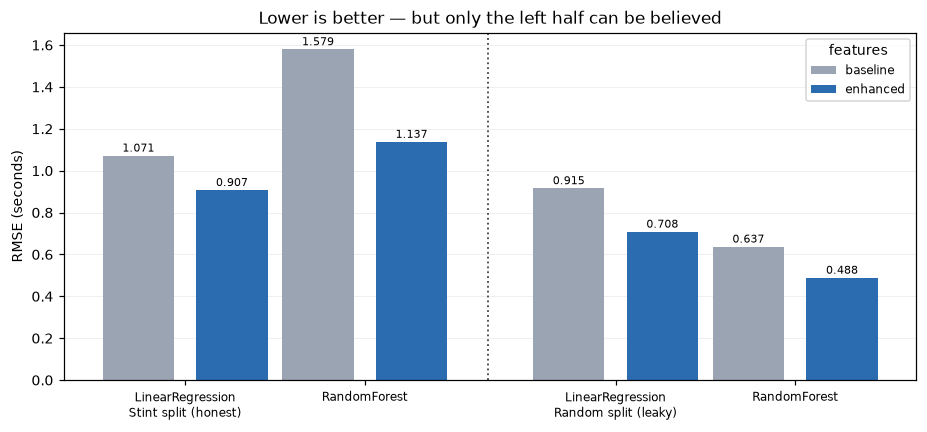

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4))

order = [("stint", "Stint split (honest)"), ("random", "Random split (leaky)")]
algos = ["LinearRegression", "RandomForest"]
width, gap = 0.19, 0.06
colours = {"baseline": "#9AA4B2", "enhanced": "#2B6CB0"}

xticks, xlabels = [], []
for si, (split, split_label) in enumerate(order):
    for ai, algo in enumerate(algos):
        centre = si * 1.15 + ai * 0.48
        for fi, fs in enumerate(["baseline", "enhanced"]):
            v = results[(results["split"] == split)
                        & (results["algorithm"] == algo)
                        & (results["features"] == fs)]["rmse"].iloc[0]
            x = centre + (fi - 0.5) * (width + gap)
            ax.bar(x, v, width=width, color=colours[fs],
                   label=fs if (si == 0 and ai == 0) else None)
            ax.text(x, v + 0.02, f"{v:.3f}", ha="center", fontsize=7.5)
        xticks.append(centre)
        xlabels.append(f"{algo}\n{split_label}" if ai == 0 else algo)

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel("RMSE (seconds)")
ax.set_title("Lower is better — but only the left half can be believed")
ax.legend(title="features", fontsize=8)
ax.grid(axis="y", alpha=0.25, lw=0.5)
ax.set_axisbelow(True)
ax.axvline(0.81, color="#444", ls=":", lw=1.2)

fig.tight_layout()
fig.savefig(ROOT / "figures" / "05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Phase 5 complete.** Tire age improves every model. On the honest split the improvement is
15.4%, and the linear model attributes 0.127s per lap to tire wear against 0.085s per lap
returned by fuel burn. The random split inflates scores by 22% to 57% and reverses which
algorithm appears better.

Phase 6 draws the required per-driver stint prediction plot.